# Exploratory Data Analysis

## Table of content
1. [Section 1: Data Inspection and Visualization](#sec1)
2. [Section 2: Weekdays and Weekend Exploration](#sec2)
3. [Section 3: Day and Month Seasonality Visualizations](#sec3)

#### Section 1: Data Inspection and Visualization <a id='sec1'></a>

In [1]:
# importing required packages
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf

In [2]:
# importing pediatric dataset on daily emergency attendances
ed_daily = pd.read_csv(
    "paediatrics_train.csv", parse_dates=True, index_col="date", dayfirst=False
)
ed_daily.index.freq = "D"

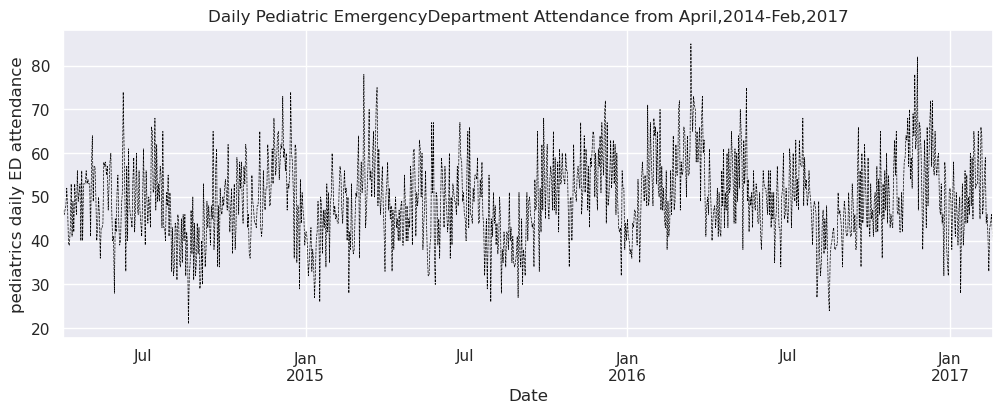

In [14]:
# Data Visualisation
sns.set()
ax = ed_daily.plot(
    figsize=(12, 4), color="black", linestyle="--", linewidth=0.5, legend=False
)
ax.set_xlabel("Date")
ax.set_ylabel("pediatrics daily ED attendance")
ax.set_title(
    "Daily Pediatric Emergency"
    "Department Attendance from April,2014-Feb,2017"
)
plt.savefig("paeds_visual.png", dpi=300)

In [4]:
# Checking the total number of days, missing values
# The earliest and latest dates, total daily ED attendances

print("No_of_days:", ed_daily.shape[0])
print("No_of_missing_values:", ed_daily.isna().sum())
print("Earliest_date:", ed_daily.index.min())
print("Latest_date:", ed_daily.index.max())
print("Total_no_ED_attends:", ed_daily.paed_ed_attends.sum())

No_of_days: 1056
No_of_missing_values: paed_ed_attends    0
dtype: int64
Earliest_date: 2014-04-01 00:00:00
Latest_date: 2017-02-19 00:00:00
Total_no_ED_attends: 52197


In [5]:
# Descriptive statistics of the data
ed_daily.describe()

,paed_ed_attends
count,1056.000000
mean,49.428977
std,9.459851
min,21.000000
25%,43.000000
50%,49.000000
75%,56.000000
max,85.000000


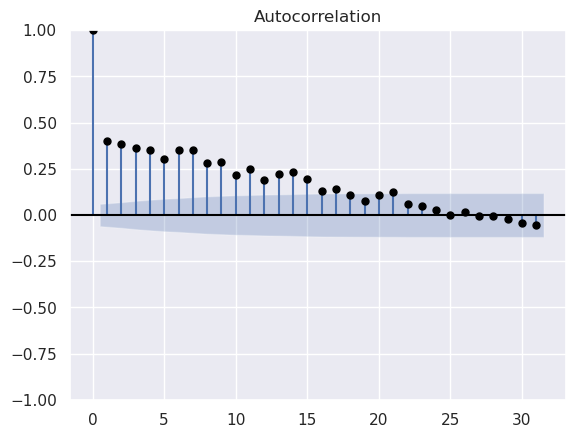

In [15]:
# An auto-correlation function plot to assess stationarity of data
_ = plot_acf(ed_daily.paed_ed_attends, color="black")
plt.savefig("hist_visual.png", dpi=300)

#### Section 2: Weekdays and Weekend Exploration <a id='sec2'></a>

In [7]:
# Converts the data into date and attendance column
ed_daily1 = ed_daily.reset_index()

In [10]:
# extracting years, months and days for analysis
ed_daily1["month_name"] = ed_daily1.date.dt.month_name()
ed_daily1["weekday"] = ed_daily1.date.dt.day_name()
ed_daily1["day_type"] = ed_daily1.date.dt.dayofweek.apply(
    lambda x: "weekend" if x >= 5 else "weekday"
)
ed_daily1["year"] = ed_daily1.date.dt.year

# Average daily attendances during weekdays and weekends per year
ed_daily1.groupby(["day_type", "year"])["paed_ed_attends"].mean().unstack()

year,2014,2015,2016,2017
day_type,,,,
weekday,47.619289,47.977011,50.758621,48.628571
weekend,50.666667,49.692308,52.190476,49.600000


In [11]:
ed_daily1.groupby("day_type")["paed_ed_attends"].mean().reset_index()

,day_type,paed_ed_attends
0,weekday,48.876658
1,weekend,50.807947


#### Section 3: Day and Month Seaonality Visualizations <a id='sec3'></a>

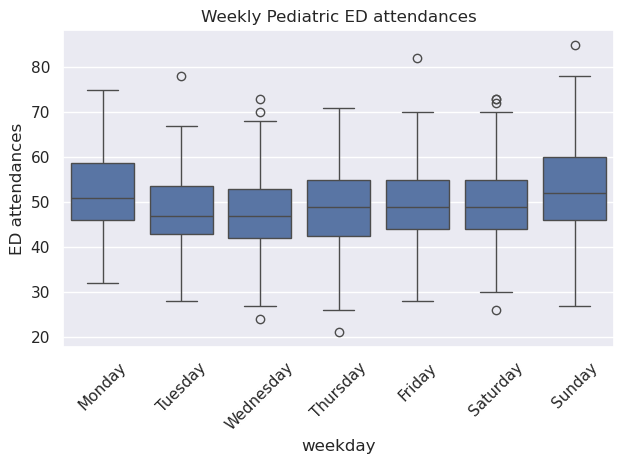

In [16]:
# Visualising day of week seasonality
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

sns.boxplot(
    x=ed_daily1.weekday,
    y=ed_daily1.paed_ed_attends,
    order=weekday_order
)
plt.xticks(rotation=45)
plt.ylabel("ED attendances")
plt.title("Weekly Pediatric ED attendances")
plt.tight_layout()
plt.savefig("weekly_ed.png", dpi=300)
plt.show()

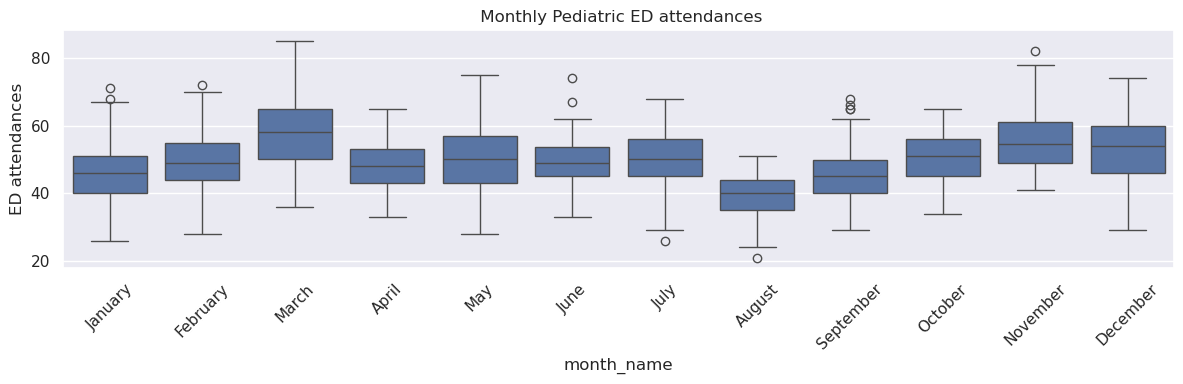

In [18]:
# Visualizing month of year seasonality
month_order = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December",
]

plt.figure(figsize=(12, 4))
sns.boxplot(
    x=ed_daily1.month_name,
    y=ed_daily1.paed_ed_attends,
    order=month_order
)

plt.xticks(rotation=45)
plt.ylabel("ED attendances")
plt.title(" Monthly Pediatric ED attendances")
plt.tight_layout()
plt.savefig("month_ed.png", dpi=300)
plt.show()